In [69]:
import os
import pandas as pd
import numpy as np

In [10]:
cwd = os.getcwd() # Поточна директорія
filePath = cwd + '/' + 'attribute_info.txt' # Файл з текстом
filePath_csv = cwd + '/' + 'agaricus-lepiota.csv' # Набір даних без імен стовбців
filePath_csv1 = cwd + '/' + 'agaricus-lepiota1.csv' # Набір даних з іменами стовбців


1. Вилученя назв показників

In [11]:
# Відкриття файлу з інформацією про показники
with open(filePath, 'r') as f:
  file_text = []
  for line in f:
    file_text.append(line)


In [29]:
# Вилученя назв показників
attributes_names = ['class']
for atr in file_text:
  name = atr[: atr.find(':')]
  name = name[atr.find('. ') + 2:]
  if len(name) != 0:
    attributes_names.append(name)

In [30]:
attributes_names

['class',
 'cap-shape',
 'cap-surface',
 'cap-color',
 'bruises?',
 'odor',
 'gill-attachment',
 'gill-spacing',
 'gill-size',
 'gill-color',
 'stalk-shape',
 'stalk-root',
 'stalk-surface-above-ring',
 'stalk-surface-below-ring',
 'stalk-color-above-ring',
 'stalk-color-below-ring',
 'veil-type',
 'veil-color',
 'ring-number',
 'ring-type',
 'spore-print-color',
 'population',
 'habitat']

2. Додавання назв стовбців в файл CSV

In [33]:
# Відкриття файлу csv
data_csv = pd.read_csv(filePath_csv, sep = ';', header = None)

# Встановлення назв стовбців
data_csv.columns = attributes_names

# Збереження DataFrame в файл CSV
data_csv.to_csv(filePath_csv1, sep = ';', index = False)

In [34]:
data_csv

,class,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
1,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
2,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
3,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
4,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8117,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8118,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8119,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8120,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [38]:
# Імпортування набору даних з встановленими назвами стовбців
import os
import pandas as pd

cwd = os.getcwd()
filePath = cwd + '/' + 'agaricus-lepiota1.csv'

df = pd.read_csv(filePath, sep = ';', header = 0)



In [39]:
df

,class,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
1,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
2,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
3,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
4,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8117,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8118,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8119,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8120,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


**Предобработка данных**
*Уникальные значения столбцов*

Определим число уникальных значений каждого показателя, чтобы выяснить:

   - какие столбцы имеют по всем строкам одинаковое значение и удалить их, так как они не несут в себе никакой полезной информации с точки зрения анализа данных;
   - какие столбцы имеют символы пропущенных значений, например: «?», NaN, NULL, None и т.д.

Получить массив уникальных значений столбца можно с помощью метода pandas.Series.unique(). Объектом Series является каждый столбец DataFrame, если обратится к нему через индексы следующим образом:

In [40]:
df.iloc[:, 0]

0       e
1       p
2       e
3       e
4       e
       ..
8117    e
8118    e
8119    e
8120    p
8121    e
Name: class, Length: 8122, dtype: object

In [41]:
type(df.iloc[:, 0])

pandas.core.series.Series

In [52]:
print(df.columns[0],  df.iloc[:, 0].unique())

class ['e' 'p']


In [53]:
for i in range(23):
  print(df.columns[i],  df.iloc[:, i].unique())

class ['e' 'p']
cap-shape ['b' 'x' 's' 'f' 'k' 'c']
cap-surface ['s' 'y' 'f' 'g']
cap-color ['w' 'g' 'y' 'n' 'e' 'p' 'b' 'u' 'c' 'r']
bruises? ['t' 'f']
odor ['l' 'p' 'n' 'a' 'f' 'c' 'y' 's' 'm']
gill-attachment ['f' 'a']
gill-spacing ['c' 'w']
gill-size ['b' 'n']
gill-color ['n' 'k' 'g' 'p' 'w' 'h' 'u' 'e' 'b' 'r' 'y' 'o']
stalk-shape ['e' 't']
stalk-root ['c' 'e' 'b' 'r' '?']
stalk-surface-above-ring ['s' 'f' 'k' 'y']
stalk-surface-below-ring ['s' 'f' 'y' 'k']
stalk-color-above-ring ['w' 'g' 'p' 'n' 'b' 'e' 'o' 'c' 'y']
stalk-color-below-ring ['w' 'p' 'g' 'b' 'n' 'e' 'y' 'o' 'c']
veil-type ['p']
veil-color ['w' 'n' 'o' 'y']
ring-number ['o' 't' 'n']
ring-type ['p' 'e' 'l' 'f' 'n']
spore-print-color ['n' 'k' 'u' 'h' 'w' 'r' 'o' 'y' 'b']
population ['n' 's' 'a' 'v' 'y' 'c']
habitat ['m' 'u' 'g' 'd' 'p' 'w' 'l']


In [55]:
# Выведем количество уникальных значений для каждого столбца:
for i in range(23):
  print(df.columns[i],  len(df.iloc[:, i].unique()))

class 2
cap-shape 6
cap-surface 4
cap-color 10
bruises? 2
odor 9
gill-attachment 2
gill-spacing 2
gill-size 2
gill-color 12
stalk-shape 2
stalk-root 5
stalk-surface-above-ring 4
stalk-surface-below-ring 4
stalk-color-above-ring 9
stalk-color-below-ring 9
veil-type 1
veil-color 4
ring-number 3
ring-type 5
spore-print-color 9
population 6
habitat 7


Так как столбец veil-type имеет лишь одно уникальное значение, то его следует удалить.

Удалить столбцы с одним уникальным значением можно с помощью метода drop(), принимающего в качестве параметра название столбца и индекс оси (axis) – 0 для удаления строки и 1 для удаления столбца:

In [56]:
for col in df.columns:
  if len(df[col].unique()) == 1:
    df = df.drop(labels = col, axis = 1)

In [58]:
for i in range(22):
  print(df.columns[i],  len(df.iloc[:, i].unique()))

class 2
cap-shape 6
cap-surface 4
cap-color 10
bruises? 2
odor 9
gill-attachment 2
gill-spacing 2
gill-size 2
gill-color 12
stalk-shape 2
stalk-root 5
stalk-surface-above-ring 4
stalk-surface-below-ring 4
stalk-color-above-ring 9
stalk-color-below-ring 9
veil-color 4
ring-number 3
ring-type 5
spore-print-color 9
population 6
habitat 7


** Поиск пропущенных значений**

Автоматизировать процесс поиска пропущенных значений бывает затруднительно в связи с разными символами пропущенных значений в каждом наборе данных. В рассматриваемом наборе данных таким символом является «?».

Выведем список столбцов с символом пропущенных значений «?»:

In [59]:
for col in df.columns:
  if '?' in df[col].unique():
    print(col, df[col].unique())

stalk-root ['c' 'e' 'b' 'r' '?']


В нашем случае только столбец «stalk-root» имеет пропущенные значения.

Подсчитаем количество пропущенных значений. Для этого необходимо взять не весь столбец таблицы DataFrame, а лишь те ячейки, которые удовлетворяют условию.

Отбор значений столбца по условию осуществляется следующим образом:

таблица[условие][условие]

Так как в нашем случае в условии необходимо указать соответствие каждого значения столбца символу «?», то команда приобретает следующий вид:
[таблица][столбец][таблица[столбец] == '?']

Подсчитать число элементов полученного массива можно с помощью функции len():

In [62]:
n = len(df['stalk-root'][df['stalk-root'] == '?'])

Таким образом мы можем вывести список столбцов с пропущенными значениями и число пропущенных значений:

In [66]:
print('stalk-root', df['stalk-root'].unique(), n, f'({round(n / len(df) * 100, 2)}%)')

stalk-root ['c' 'e' 'b' 'r' '?'] 2480 (30.53%)


Обработка пропущенных значений

Существуют разные стратегии обработки пропущенных значений, зависящие от исследуемого набора данных:

·       Если строк с пропущенными значениями несколько процентов от общего числа строк в наборе данных, то такие строки удаляют.

·       Если строка или столбец имеет 100% пропущенных значений, то такой столбец или строку удаляют.

·       Если пропущенных значений около 50% от общего числа значений в столбце, то удаление таких строк приведет к потере информации об исходных данных. Тогда такие значения заменяются на средние, либо на значения из соседних ячеек.

·       В отдельных случаях пропущенные значения могут влиять на классификацию и их необходимо учитывать при обучении модели. Тогда такие значения заменяются на дополнительное уникальное числовое значение.

Таким образом можно выделить следующие способы обработки пропущенных значений для каждого качественного показателя:

1.    Удаление строк с пропущенными значениями.

2.    Удаление столбца с пропущенными значениями.

3.    Заполнение ячеек с пропущенными значениями новым уникальным значением.

4.    Использование методов прямого и обратного заполнения:

a.     Метод прямого заполнения – заполнение каждой пустой ячейки значением последней непустой ячейки из предыдущих ячеек (движение с начала в конец).

b.    Метод обратного заполнения – заполнение каждой пустой ячейки значением первой непустой ячейки из последующих ячеек (движение с конца в начало).

В нашем случае 31% строк только по столбцу «stalk-root» имеют пропущенные значения. Рассмотрим все 4 способа обработки пропущенных значений.

1. Удаление строк

Удалять почти треть строк из-за одного столбца нецелесообразно.

Однако, если бы доля строк с пропущенными значениями составляла несколько процентов, то удаление строк можно было бы реализовать через обновление таблицы, взяв только те ее строки, которые удовлетворяют условию:

*table = table[condition]*

В нашем случае необходимо взять те строки, чтобы значения определенного столбца по этим строкам не были равны символу «?»:

*table = table[table[column] != '?']*

То есть команда будет выглядеть следующим образом:

df = df[df['stalk-root'] != '?']




In [67]:
df = df[df['stalk-root'] != '?']

In [68]:
df

,class,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,e,b,s,w,t,l,f,c,b,n,...,s,s,w,w,w,o,p,n,n,m
1,p,x,y,w,t,p,f,c,n,n,...,s,s,w,w,w,o,p,k,s,u
2,e,x,s,g,f,n,f,w,b,k,...,s,s,w,w,w,o,e,n,a,g
3,e,x,y,y,t,a,f,c,b,n,...,s,s,w,w,w,o,p,k,n,g
4,e,b,s,w,t,a,f,c,b,g,...,s,s,w,w,w,o,p,k,n,m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7984,e,b,y,n,f,n,f,c,b,w,...,y,y,n,n,w,t,p,w,y,p
7999,e,x,y,n,f,n,f,c,b,w,...,y,y,n,n,w,t,p,w,y,p
8036,e,x,y,g,t,n,f,c,b,w,...,s,s,w,w,w,t,p,w,y,p
8093,p,x,y,c,f,m,f,c,b,y,...,k,y,c,c,w,n,n,w,c,d


2. Удаление столбца

Одним из возможных решений в нашем случае является удаление столбца. Однако данный показатель может быть важным для исследователя и играть существенную роль в классификации.

Удаление столбца осуществляется с помощью метода drop(), либо ключевого слова del:

df = df.drop(labels = 'stalk-root', axis = 1)


del df['stalk-root']

3. Новое уникальное значение

Заполнение пустых ячеек новым уникальным значением можно осуществить следующим образом. Сначала пропущенные значения заменяются на NaN (через np.nan). Затем с помощью метода fillna() все значения NaN заменяются на 0:

df['stalk-root'][df['stalk-root'] == '?'] = np.nan # Замена ? на nan


df['stalk-root'] = df['stalk-root'].fillna(value = 0) # Замена nan на 0

Здесь можно было бы сразу символы «?» заменять на 0, однако метод fillna() используется при реализации прямого и обратного заполнения.

4. Метод прямого заполнения

df['stalk-root'][df['stalk-root'] == '?'] = np.nan # Замена ? на nan

df['stalk-root'] = df['stalk-root'].fillna(method = 'ffill') # method

5. Метод обратного заполнения

df['stalk-root'][df['stalk-root'] == '?'] = np.nan # Замена ? на nan

df['stalk-root'] = df['stalk-root'].fillna(method = 'bfill') # method


Выберем 3 способ обработки пропущенных значений. То есть символы «?» заменим на 0, проверим уникальные значения измененного столбца и сохраним набор данных в файле agaricus-lepiota2.csv:

In [72]:
df['stalk-root'][df['stalk-root'] == '?'] = np.nan # Замена ? на nan
df['stalk-root'] = df['stalk-root'].fillna(value = 0) # Замена nan на 0
print(df['stalk-root'].unique())
df.to_csv(path_or_buf = filePath.replace('1.csv', '2.csv'), sep = ';', index = False)

['c' 'e' 'b' 'r']


**Преобразование качественных данных**

Набор данных Mushroom Data Set содержит только качественные данные. Чтобы проводить анализ таких данных их требуется сначала привести в числовой вид, то есть для каждого уникального значения столбца необходимо привести в соответствие уникальное числовое значение. Например, для столбца «class» значения e (не ядовитый), p (ядовитый) нужно заменить на 0 (не ядовитый), 1 (ядовитый).

Преобразовать символьные значения качественной переменной в цифровые можно с помощью класса sklearn.preprocessing.LabelEncoder библиотеки scikit-learn.

В программном коде ниже исходные значения столбца «class» сохраняются в переменную data_raw, а преобразованные – в переменную data_transform:

In [75]:
from sklearn import preprocessing

le = preprocessing.LabelEncoder() # Создание экземпляра класса

#Исходные значения
data_raw = df['class']

le.fit(data_raw) # Заполнение экземпляра исходным мыссивом
print("Классы:", le.classes_) # Классы(уникальные значения исходного массива)

# Преобразованные значения
data_transform = le.transform(data_raw) # Преобразование (преобразованный массив)
print('\nПреобразованный массив \n', data_transform)
print('Классы:', np.unique(data_transform)) # Классы (уникальные значения преобразованного массива)

Классы: ['e' 'p']

Преобразованный массив 
 [0 1 0 ... 0 1 1]
Классы: [0 1]


Таким образом, массив значений e, p был преобразован в массив значений 0, 1.

Создадим таблицу преобразованных значений df_transform типа DataFrame. Добавление столбца в таблицу осуществляется следующим образом:

table[new_column] = массив_значений

In [77]:
# таблица преобразованых значений
df_transform = pd.DataFrame() # empty table
df_transform['class'] = data_transform # add the column



In [78]:
df_transform

,class
0,0
1,1
2,0
3,0
4,0
...,...
5637,0
5638,0
5639,0
5640,1


In [79]:
df_transform = pd.DataFrame()

In [80]:
for col in df.columns:
  data_raw = df[col]
  le.fit(data_raw)
  data_transform = le.transform(data_raw)
  df_transform[col] = data_transform

In [81]:
df_transform

,class,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,0,0,2,6,1,3,1,0,0,3,...,2,2,5,5,0,1,3,2,2,3
1,1,5,3,6,1,6,1,0,1,3,...,2,2,5,5,0,1,3,1,3,5
2,0,5,2,3,0,5,1,1,0,2,...,2,2,5,5,0,1,0,2,0,1
3,0,5,3,7,1,0,1,0,0,3,...,2,2,5,5,0,1,3,1,2,1
4,0,0,2,6,1,0,1,0,0,0,...,2,2,5,5,0,1,3,1,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5637,0,0,3,4,0,5,1,0,0,7,...,3,3,3,3,0,2,3,5,5,4
5638,0,5,3,4,0,5,1,0,0,7,...,3,3,3,3,0,2,3,5,5,4
5639,0,5,3,3,1,5,1,0,0,7,...,2,2,5,5,0,2,3,5,5,4
5640,1,5,3,1,0,4,1,0,0,8,...,1,3,1,1,0,0,2,5,1,0


Для проверки правильности команд мы можем вывести уникальные значения исходных столбцов (таблица df) и преобразованных столбцов (таблица df_transform):

In [82]:
for i in range(22):
  print(df.columns[i],  df.iloc[:, i].unique(), df_transform.iloc[:, i].unique())

class ['e' 'p'] [0 1]
cap-shape ['b' 'x' 's' 'f' 'k' 'c'] [0 5 4 2 3 1]
cap-surface ['s' 'y' 'f' 'g'] [2 3 0 1]
cap-color ['w' 'g' 'y' 'n' 'e' 'p' 'b' 'c'] [6 3 7 4 2 5 0 1]
bruises? ['t' 'f'] [1 0]
odor ['l' 'p' 'n' 'a' 'f' 'c' 'm'] [3 6 5 0 2 1 4]
gill-attachment ['f' 'a'] [1 0]
gill-spacing ['c' 'w'] [0 1]
gill-size ['b' 'n'] [0 1]
gill-color ['n' 'k' 'g' 'p' 'w' 'h' 'u' 'r' 'y'] [3 2 0 4 7 1 6 5 8]
stalk-shape ['e' 't'] [0 1]
stalk-root ['c' 'e' 'b' 'r'] [1 2 0 3]
stalk-surface-above-ring ['s' 'f' 'k' 'y'] [2 0 1 3]
stalk-surface-below-ring ['s' 'f' 'y' 'k'] [2 0 3 1]
stalk-color-above-ring ['w' 'g' 'p' 'n' 'b' 'c' 'y'] [5 2 4 3 0 1 6]
stalk-color-below-ring ['w' 'p' 'g' 'b' 'n' 'c' 'y'] [5 4 2 0 3 1 6]
veil-color ['w' 'y'] [0 1]
ring-number ['o' 't' 'n'] [1 2 0]
ring-type ['p' 'e' 'l' 'n'] [3 0 1 2]
spore-print-color ['n' 'k' 'u' 'h' 'r' 'w'] [2 1 4 0 3 5]
population ['n' 's' 'a' 'v' 'y' 'c'] [2 3 0 4 5 1]
habitat ['m' 'u' 'g' 'd' 'p' 'l'] [3 5 1 0 4 2]


По данному списку видно соответствие уникальных буквенных значений исходных столбцов уникальным числовым значениям преобразованных столбцов.

Сохраним преобразованные данные в файл agaricus-lepiota3.csv.

In [85]:
df_transform.to_csv(path_or_buf = filePath.replace('1.csv', '3.csv'), sep = ';', index = False)

Преобразование количественных данных

Преобразование количественных данных – изменение исходных данных с целью достижения необходимых условий для применения того или иного метода анализа или линейной модели (например, для стабилизации дисперсии, для приведения распределения к нормальной форме).

1. Логарифмирование

Логарифмическое преобразование как зависимых (Y), так и независимых переменных (X) часто используется на практике. При этом, экономисты зачастую работают с натуральными логарифмами, для которых используется символ .

y = ln(x)

где x – преобразуемые (исходные) данные,

y – преобразованные данные.

Применение:

·       Дисперсионный анализ: для того, чтобы эффекты воздействия факторов суммировались, а не перемножались.


2. Преобразование к обратному корню

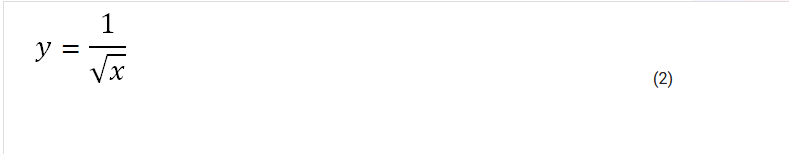

3. Преобразование Бокса-Кокса

Преобразование Бокса-Кокса – обобщение степенных преобразований:

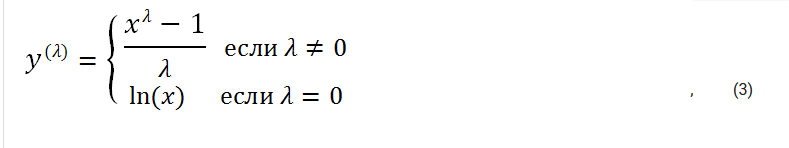


где лямбда – параметр преобразования.

Преобразование Бокса-Кокса применимо только для положительных переменных. Если переменные содержат отрицательные значения, можно либо сдвинуть распределение, добавив константу, либо использовать преобразование Йео-Джонсона.


4. Стандартизация

Стандартизация данных – процесс приведения вектора каждого признака к такому виду, что его математическое ожидание станет нулевым, а дисперсия – единичной:

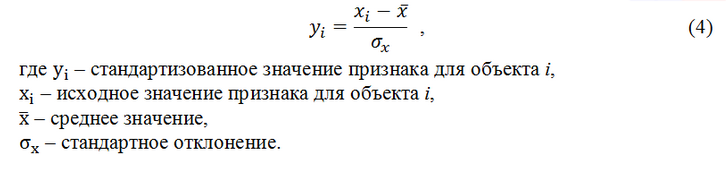


Применение: для смещения значений признака относительно единого центра в нуле, выравнивания разброса значений.


5. Нормализация

Нормализация – процесс масштабирования вектора каждого признака, то есть приведение его к такому виду, что вектор будет иметь единичную норму (при этом есть разные способы оценки или подсчета нормы).

Применение: для приведения значений признака к одинаковому масштабу, например к диапазону [0; 1].

Виды: max-норма (5), L1-норма (6), L2-норма (7).

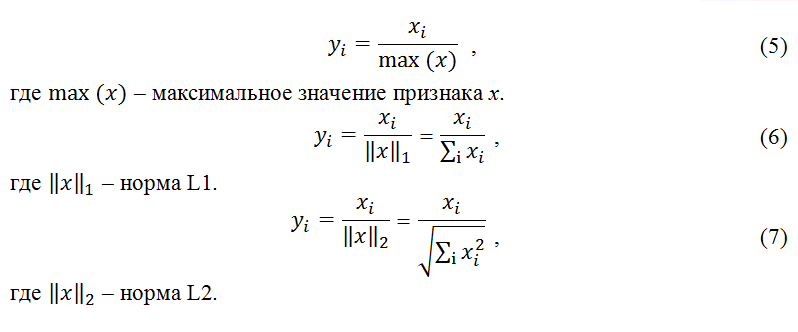